# Clustering Crédit - Partie 2: Algorithmes & Comparaison Interactive

🎯 **Objectif**: Appliquer et comparer K-Means, CAH et DBSCAN sur les données clients

📋 **Ce que vous allez faire**:
1. Standardiser les données préparées en Partie 1
2. Appliquer K-Means avec différents K
3. Tester le clustering hiérarchique (CAH)
4. Expérimenter DBSCAN
5. Comparer les résultats avec des métriques

💡 **Rappel**: Vous segmentez des clients de crédit pour personnaliser les offres marketing.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, interactive
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print("🚀 Environnement prêt pour le clustering!")

🚀 Environnement prêt pour le clustering!


## 📂 Étape 1: Chargement des données préparées

Chargeons les données de la Partie 1 ou créons un jeu de test.

In [15]:
try:
    # Tentative de chargement depuis Partie 1
    X_raw = pd.read_csv('donnees_clustering_partie1.csv')
    print("✅ Données chargées depuis la Partie 1")
    print(f"📏 Dimensions: {X_raw.shape}")
    display(X_raw.head())
except FileNotFoundError:
    print("⚠️ Fichier de la Partie 1 non trouvé. Création d'un jeu de test...")
    
    # Création d'un dataset de démonstration
    np.random.seed(42)
    n_samples = 800
    
    X_raw = pd.DataFrame({
        'AGE': np.random.normal(35, 10, n_samples),
        'utilization': np.random.beta(2, 5, n_samples),
        'repay_ratio_recent': np.random.beta(3, 2, n_samples),
        'nb_retards': np.random.poisson(1.2, n_samples),
        'facture_moyenne': np.random.lognormal(8, 1, n_samples),
        'paiement_moyen': np.random.lognormal(7.5, 1.2, n_samples)
    })
    
    print("✅ Jeu de données de démonstration créé")
    print(f"📏 Dimensions: {X_raw.shape}")

✅ Données chargées depuis la Partie 1
📏 Dimensions: (1000, 4)


,AGE,utilization,repay_ratio_recent,nb_retards
0,25,0.295467,0.169224,0
1,26,0.911573,0.032808,0
2,32,1.001743,0.034668,0
3,49,0.159062,0.077861,0
4,36,1.884560,0.021225,1


## 🔧 Étape 2: Standardisation Interactive

La standardisation est cruciale pour que toutes les variables aient le même poids.

In [ ]:
@interact(
    methode=Dropdown(options=['StandardScaler', 'MinMaxScaler', 'RobustScaler'], 
                    value='StandardScaler', description='Méthode:'),
    afficher=Dropdown(options=['Avant/Après', 'Statistiques', 'Distributions'], 
                     value='Avant/Après', description='Affichage:')
)
def standardiser_donnees(methode, afficher):
    """Standardisation interactive des données"""
    from sklearn.preprocessing import MinMaxScaler, RobustScaler
    
    # Choix du scaler
    if methode == 'StandardScaler':
        scaler = StandardScaler()
        desc = "Moyenne=0, Écart-type=1"
    elif methode == 'MinMaxScaler':
        scaler = MinMaxScaler()
        desc = "Valeurs entre 0 et 1"
    else:
        scaler = RobustScaler()
        desc = "Médiane=0, résistant aux outliers"
    
    # Application
    X_scaled = scaler.fit_transform(X_raw)
    X_scaled_df = pd.DataFrame(X_scaled, columns=X_raw.columns)
    
    if afficher == 'Avant/Après':
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        
        # Avant
        X_raw.boxplot(ax=axes[0])
        axes[0].set_title('Données brutes')
        axes[0].tick_params(axis='x', rotation=45)
        
        # Après
        X_scaled_df.boxplot(ax=axes[1])
        axes[1].set_title(f'Après {methode}\n({desc})')
        axes[1].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        
    elif afficher == 'Statistiques':
        print("📊 Statistiques avant standardisation:")
        display(X_raw.describe().round(2))
        
        print(f"\n📊 Statistiques après {methode}:")
        display(X_scaled_df.describe().round(2))
        
    elif afficher == 'Distributions':
        # Histogrammes comparatifs
        n_vars = len(X_raw.columns)
        fig, axes = plt.subplots(2, n_vars, figsize=(4*n_vars, 8))
        
        for i, col in enumerate(X_raw.columns):
            # Avant
            axes[0, i].hist(X_raw[col], bins=20, alpha=0.7, edgecolor='black')
            axes[0, i].set_title(f'{col} (brut)')
            
            # Après
            axes[1, i].hist(X_scaled_df[col], bins=20, alpha=0.7, edgecolor='black')
            axes[1, i].set_title(f'{col} ({methode})')
        
        plt.tight_layout()
    
    plt.show()
    
    # Sauvegarde pour les étapes suivantes
    global X_standardise
    X_standardise = X_scaled
    
    return X_scaled

# Standardisation par défaut
scaler = StandardScaler()
X_standardise = scaler.fit_transform(X_raw)
print("✅ Données standardisées (StandardScaler par défaut)")

interactive(children=(Dropdown(description='Méthode:', options=('StandardScaler', 'MinMaxScaler', 'RobustScale…

✅ Données standardisées (StandardScaler par défaut)


In [9]:
# Sélectionnez seulement les variables métier continues
variables_clustering = ['utilization', 'repay_ratio_recent', 'repay_ratio_mean', 
                       'nb_retards', 'facture_moyenne', 'paiement_moyen']

X_clustering = X_raw[variables_clustering]
scaler = StandardScaler()
X_standardise = scaler.fit_transform(X_clustering)

## 🎯 Étape 3: K-Means Interactif

Explorez l'effet du nombre de clusters K sur la segmentation.

In [16]:
def plot_clusters_simple(X, labels, title="Clusters"):
    """Visualisation simple des clusters (2 premières variables)"""
    plt.figure(figsize=(12, 5))
    
    # Scatter plot
    plt.subplot(1, 2, 1)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.7)
    plt.xlabel(X_raw.columns[0])
    plt.ylabel(X_raw.columns[1])
    plt.title(title)
    plt.colorbar(scatter)
    
    # Tailles des clusters
    plt.subplot(1, 2, 2)
    unique, counts = np.unique(labels, return_counts=True)
    colors = ['gray' if u == -1 else plt.cm.viridis(i/len(unique)) for i, u in enumerate(unique)]
    plt.bar([str(u) for u in unique], counts, color=colors)
    plt.title('Taille des segments')
    plt.xlabel('Cluster')
    plt.ylabel('Nombre de clients')
    
    plt.tight_layout()
    plt.show()

@interact(
    k=IntSlider(min=2, max=10, step=1, value=4, description='Nombre K:'),
    n_init=IntSlider(min=1, max=20, step=1, value=10, description='Initialisations:'),
    afficher_metriques=Dropdown(options=['Oui', 'Non'], value='Oui', description='Métriques:')
)
def kmeans_interactif(k, n_init, afficher_metriques):
    """K-Means interactif"""
    # Application K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=n_init)
    labels = kmeans.fit_predict(X_standardise)
    
    # Visualisation
    plot_clusters_simple(X_standardise, labels, f'K-Means (K={k})')
    
    # Métriques
    if afficher_metriques == 'Oui':
        sil = silhouette_score(X_standardise, labels)
        cal = calinski_harabasz_score(X_standardise, labels)
        dav = davies_bouldin_score(X_standardise, labels)
        
        print(f"📊 Métriques pour K={k}:")
        print(f"  • Silhouette: {sil:.3f} (↑ mieux)")
        print(f"  • Calinski-Harabasz: {cal:.1f} (↑ mieux)")
        print(f"  • Davies-Bouldin: {dav:.3f} (↓ mieux)")
        
        # Inertie
        print(f"  • Inertie: {kmeans.inertia_:.1f}")
    
    return labels

interactive(children=(IntSlider(value=4, description='Nombre K:', max=10, min=2), IntSlider(value=10, descript…

## 🌳 Étape 4: Clustering Hiérarchique (CAH) Interactif

Testez différentes méthodes de liaison (linkage).

In [17]:
@interact(
    k=IntSlider(min=2, max=8, step=1, value=4, description='Nombre K:'),
    linkage=Dropdown(options=['ward', 'complete', 'average', 'single'], 
                    value='ward', description='Liaison:'),
    afficher_dendro=Dropdown(options=['Non', 'Oui'], value='Non', description='Dendrogramme:')
)
def cah_interactif(k, linkage, afficher_dendro):
    """CAH interactif"""
    from scipy.cluster.hierarchy import dendrogram, linkage as scipy_linkage
    
    # Application CAH
    cah = AgglomerativeClustering(n_clusters=k, linkage=linkage)
    labels = cah.fit_predict(X_standardise)
    
    # Visualisation des clusters
    plot_clusters_simple(X_standardise, labels, f'CAH (K={k}, {linkage})')
    
    # Dendrogramme (optionnel)
    if afficher_dendro == 'Oui':
        plt.figure(figsize=(12, 4))
        Z = scipy_linkage(X_standardise[:100], method=linkage)  # Sous-échantillon pour lisibilité
        dendrogram(Z, truncate_mode='level', p=5)
        plt.title(f'Dendrogramme (méthode: {linkage})')
        plt.show()
    
    # Métriques
    sil = silhouette_score(X_standardise, labels)
    cal = calinski_harabasz_score(X_standardise, labels)
    dav = davies_bouldin_score(X_standardise, labels)
    
    print(f"📊 Métriques CAH (K={k}, {linkage}):")
    print(f"  • Silhouette: {sil:.3f}")
    print(f"  • Calinski-Harabasz: {cal:.1f}")
    print(f"  • Davies-Bouldin: {dav:.3f}")
    
    return labels

interactive(children=(IntSlider(value=4, description='Nombre K:', max=8, min=2), Dropdown(description='Liaison…

## 🔍 Étape 5: DBSCAN Interactif

DBSCAN ne nécessite pas de spécifier K à l'avance et détecte le bruit.

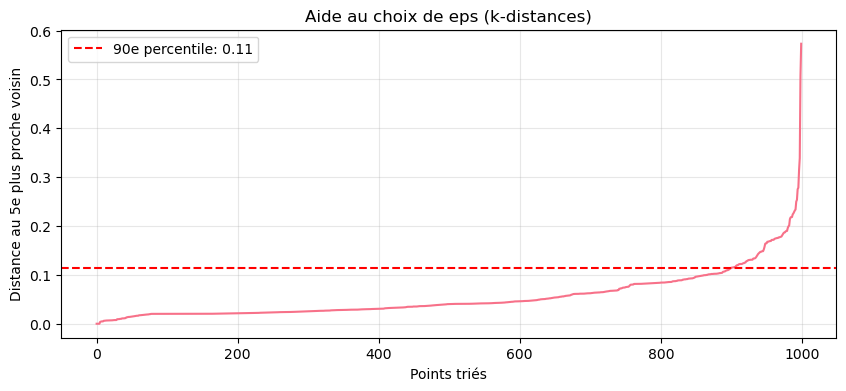

interactive(children=(FloatSlider(value=0.11363902604302856, description='eps:', max=2.0, min=0.1, step=0.05),…

In [20]:
# Aide pour choisir eps
def estimer_eps(X, k=5):
    """Estime eps via la méthode k-dist"""
    nbrs = NearestNeighbors(n_neighbors=k).fit(X)
    distances, _ = nbrs.kneighbors(X)
    k_distances = np.sort(distances[:, k-1])
    return k_distances

k_dist = estimer_eps(X_standardise)

plt.figure(figsize=(10, 4))
plt.plot(k_dist)
plt.title('Aide au choix de eps (k-distances)')
plt.xlabel('Points triés')
plt.ylabel('Distance au 5e plus proche voisin')
plt.grid(True, alpha=0.3)
plt.axhline(y=np.percentile(k_dist, 90), color='red', linestyle='--', 
           label=f'90e percentile: {np.percentile(k_dist, 90):.2f}')
plt.legend()
plt.show()

@interact(
    eps=FloatSlider(min=0.1, max=2.0, step=0.05, 
                   value=float(np.percentile(k_dist, 90)), description='eps:'),
    min_samples=IntSlider(min=3, max=20, step=1, value=5, description='min_samples:')
)
def dbscan_interactif(eps, min_samples):
    """DBSCAN interactif"""
    # Application DBSCAN
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_standardise)
    
    # Statistiques
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_ratio = n_noise / len(labels)
    
    # Visualisation
    plot_clusters_simple(X_standardise, labels, 
                        f'DBSCAN (eps={eps:.2f}, min_samples={min_samples})')
    
    print(f"📊 Résultats DBSCAN:")
    print(f"  • Clusters trouvés: {n_clusters}")
    print(f"  • Points de bruit: {n_noise} ({noise_ratio:.1%})")
    
    # Métriques (si applicable)
    if n_clusters > 1 and n_noise < len(labels):
        try:
            sil = silhouette_score(X_standardise, labels)
            print(f"  • Silhouette: {sil:.3f}")
        except:
            print("  • Silhouette: Non calculable")
    
    return labels

## 📊 Étape 6: Comparaison des Algorithmes

Comparons les trois méthodes avec des paramètres optimaux.

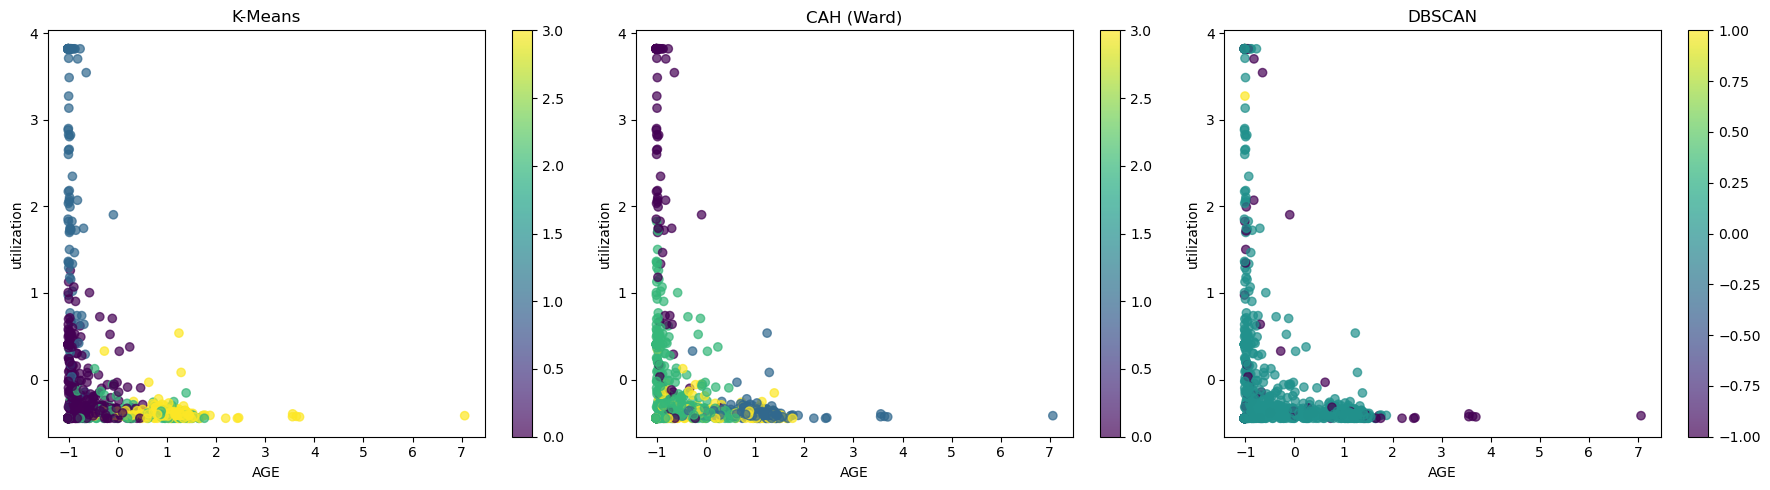

📊 Comparaison des algorithmes:


,Algorithme,Clusters,Bruit,Silhouette
0,K-Means,4,0,0.351
1,CAH,4,0,0.336
2,DBSCAN,2,67,0.390


In [19]:
def comparer_algorithmes():
    """Compare K-Means, CAH et DBSCAN"""
    
    # Paramètres par défaut
    K_DEFAULT = 4
    EPS_DEFAULT = float(np.percentile(k_dist, 90))
    
    # Application des 3 algorithmes
    kmeans = KMeans(n_clusters=K_DEFAULT, random_state=42, n_init=10)
    labels_km = kmeans.fit_predict(X_standardise)
    
    cah = AgglomerativeClustering(n_clusters=K_DEFAULT, linkage='ward')
    labels_cah = cah.fit_predict(X_standardise)
    
    dbscan = DBSCAN(eps=EPS_DEFAULT, min_samples=5)
    labels_db = dbscan.fit_predict(X_standardise)
    
    # Visualisations côte à côte
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for ax, labels, title in zip(axes, 
                                [labels_km, labels_cah, labels_db],
                                ['K-Means', 'CAH (Ward)', 'DBSCAN']):
        scatter = ax.scatter(X_standardise[:, 0], X_standardise[:, 1], 
                           c=labels, cmap='viridis', alpha=0.7)
        ax.set_xlabel(X_raw.columns[0])
        ax.set_ylabel(X_raw.columns[1])
        ax.set_title(title)
        plt.colorbar(scatter, ax=ax)
    
    plt.tight_layout()
    plt.show()
    
    # Tableau comparatif des métriques
    resultats = []
    
    for nom, labels in [('K-Means', labels_km), ('CAH', labels_cah), ('DBSCAN', labels_db)]:
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1) if -1 in labels else 0
        
        try:
            sil = silhouette_score(X_standardise, labels) if n_clusters > 1 else np.nan
        except:
            sil = np.nan
            
        resultats.append({
            'Algorithme': nom,
            'Clusters': n_clusters,
            'Bruit': n_noise,
            'Silhouette': sil
        })
    
    df_resultats = pd.DataFrame(resultats)
    print("📊 Comparaison des algorithmes:")
    display(df_resultats.round(3))
    
    return labels_km, labels_cah, labels_db

# Exécution de la comparaison
labels_km, labels_cah, labels_db = comparer_algorithmes()

## ✅ Récapitulatif Partie 2

🎉 **Félicitations!** Vous avez testé les 3 algorithmes de clustering.

**Ce que vous avez appris:**
- Standardiser les données avant clustering
- Paramétrer K-Means (choix de K, initialisations)
- Utiliser CAH avec différentes méthodes de liaison
- Configurer DBSCAN (eps, min_samples)
- Comparer les algorithmes avec des métriques

**Métriques importantes:**
- **Silhouette** (0 à 1): cohésion interne vs séparation externe (↑ mieux)
- **Calinski-Harabasz**: ratio variance inter/intra clusters (↑ mieux)  
- **Davies-Bouldin**: moyenne des ratios intra/inter par cluster (↓ mieux)

**Choix d'algorithme:**
- **K-Means**: rapide, clusters sphériques, nécessite K
- **CAH**: hiérarchie, formes variées, coûteux en calcul
- **DBSCAN**: détecte bruit, pas de K, sensible aux paramètres

**➡️ Prochaine étape:** Partie 3 - Interprétation business et recommandations marketing